Text(0.5, 1.0, 'f(x)')

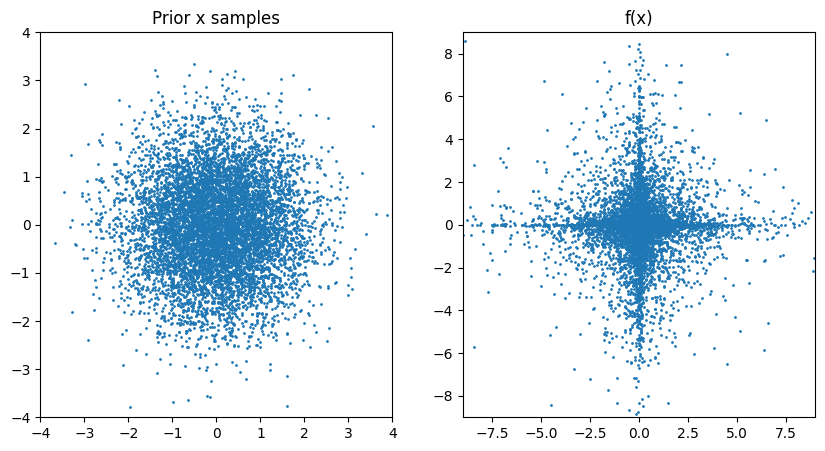

In [15]:
from matplotlib import pyplot as plt
import torch
from kemsekov_torch.log_prop_approx import log_prob, log_prob_inverse

def f(x):
    return torch.sign(x)*x*x

x = torch.randn((8192,2))
y = f(x)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.scatter(x[:,0],x[:,1],s=1)
plt.title("Prior x samples")
plt.subplot(1,2,2)
plt.scatter(y[:,0],y[:,1],s=1)
plt.xlim(-9,9)
plt.ylim(-9,9)
plt.title("f(x)")

In [16]:
import numpy as np
def exact_density(y):
    """
    Computes the exact probability density of y = sign(x)*x^2 
    where x ~ N(0, 1) element-wise.
    
    Args:
        y: Tensor of any shape
        
    Returns:
        Tensor of same shape with log-probability density values
    """
    # Avoid division by zero at y=0 (density goes to infinity)
    # Add small epsilon for numerical stability if needed, 
    # but mathematically it is undefined at 0.
    abs_y = torch.abs(y)
    
    # Handle y=0 case separately if necessary, but for plotting/hist comparison
    # we usually mask out very small values or add epsilon.
    eps = 1e-9
    safe_abs_y = torch.clamp(abs_y, min=eps)
    
    # 1D Log Density: log(1/(2*sqrt(2*pi*|y|))) - |y|/2
    # = -log(2) - 0.5*log(2*pi) - 0.5*log(|y|) - |y|/2
    log_prob_1d = (
        -torch.log(torch.tensor(2.0)) 
        - 0.5 * torch.log(torch.tensor(2 * np.pi)) 
        - 0.5 * torch.log(safe_abs_y) 
        - 0.5 * safe_abs_y
    )
    
    # For 2D independent data, sum the log probs
    if y.dim() == 2 and y.shape[1] == 2:
        log_prob_2d = log_prob_1d.sum(dim=1)
        return log_prob_2d
    else:
        return log_prob_1d
    

Text(0.5, 1.0, 'Exact logprob')

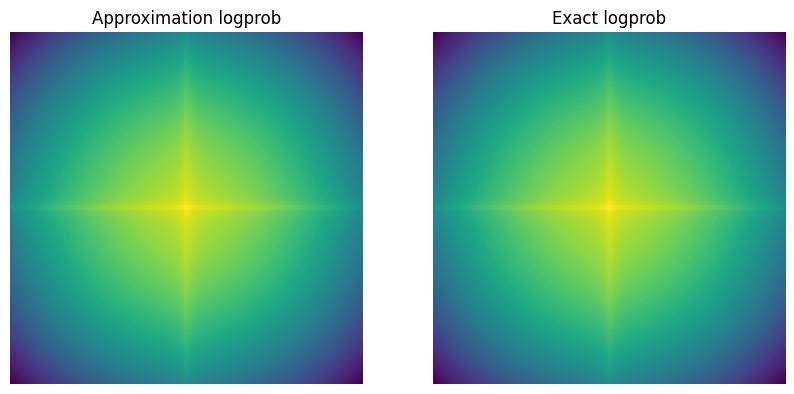

In [17]:
import math

X = torch.linspace(-6,6,128)
Y = torch.linspace(-6,6,128)
grid = torch.stack(torch.meshgrid([X,Y],indexing="ij"),-1)
x = grid.view(-1,2)

true_logp=exact_density(f(x)).view(grid.shape[:-1])
logp = log_prob(f,x).view(grid.shape[:-1])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow((logp.T))
plt.axis('off')
plt.title("Approximation logprob")
plt.subplot(1,2,2)
plt.imshow((true_logp.T))
plt.axis('off')
plt.title("Exact logprob")

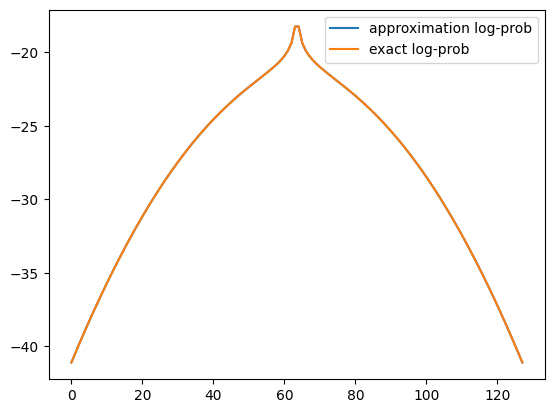

In [21]:
plt.plot(logp[:,3],label='approximation log-prob')
plt.plot(true_logp[:,3],label='exact log-prob')
plt.legend()